In [1]:
import pandas as pd
import statsmodels.api as sm

In [2]:
data = pd.read_csv('Airpassengers.csv', parse_dates=['Month'], index_col='Month')
data

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


<Axes: xlabel='Month'>

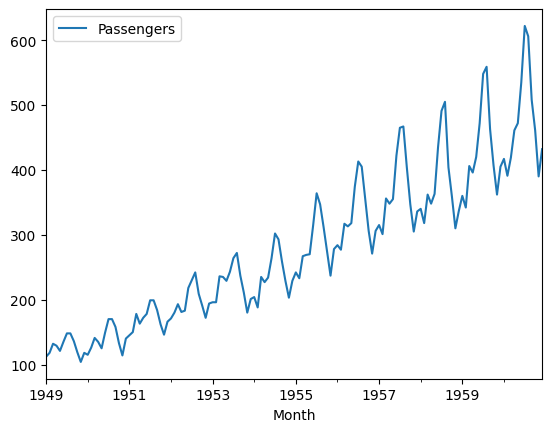

In [4]:
data.plot()

<Axes: xlabel='Month'>

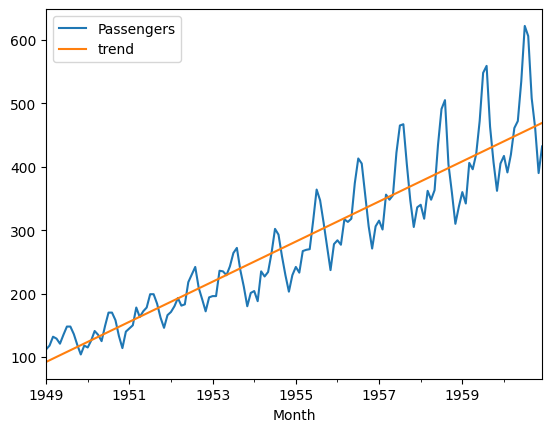

In [5]:
X = [ i + 35 for i in range(len(data.index)) ]
model = sm.OLS(data, X )
res = model.fit()
data['trend'] = res.fittedvalues
data.plot()

<Axes: xlabel='Month'>

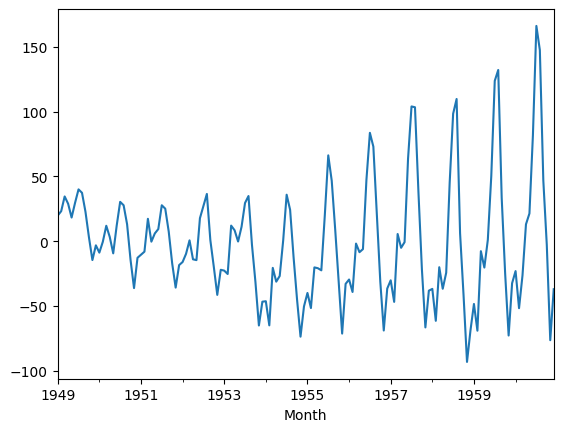

In [6]:
data['residual'] = data['Passengers'] - data['trend']
data.residual.plot()

In [7]:
data.residual.mean()

np.float64(-0.3558213750852153)

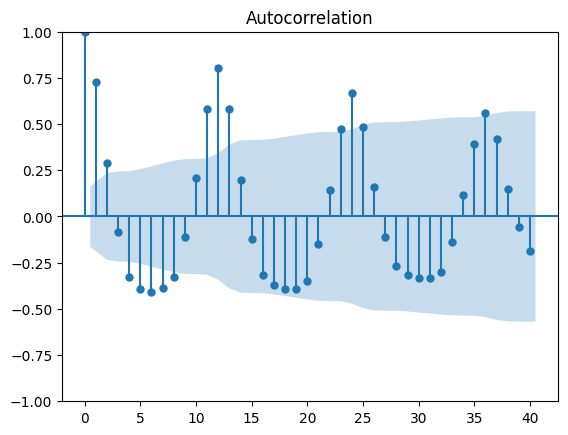

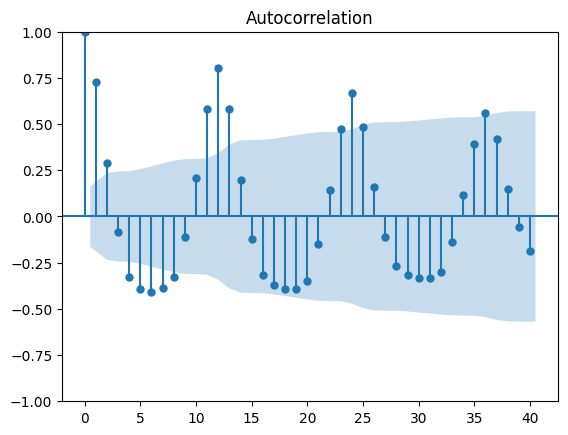

In [8]:
sm.graphics.tsa.plot_acf(data.residual, alpha=0.05,lags=40)

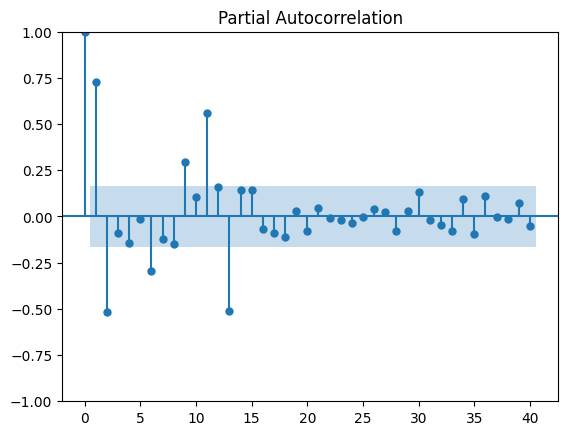

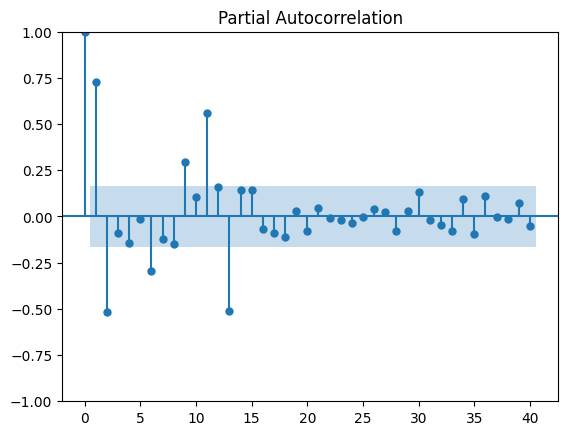

In [9]:
sm.graphics.tsa.plot_pacf(data.residual,alpha=0.05, lags=40)

<Axes: xlabel='Month'>

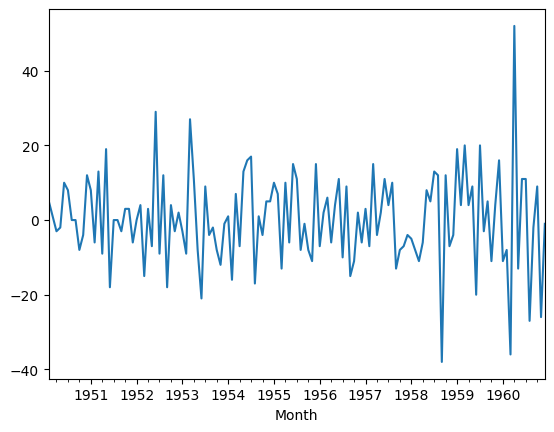

In [10]:
sm.tsa.statespace.tools.diff(data['Passengers'], k_diff=1, k_seasonal_diff=1,seasonal_periods=12).plot()

<Axes: xlabel='Month'>

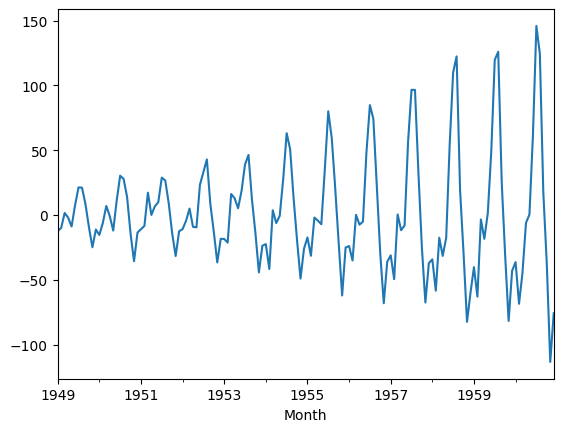

In [11]:
data["residual"] = data["Passengers"] - data["Passengers"].rolling(window=12, min_periods=1,center=True).mean()
data.residual.plot()